# California Housing Price Regression
A Random Forest regression model predicting median house values using the California Housing dataset.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

## 2. Load Data

In [2]:
# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Feature Engineering
New features derived from raw columns:
- `rooms_per_person` — avg rooms per occupant (captures crowding)
- `bedrooms_ratio` — bedrooms as a fraction of total rooms
- `income_per_room` — income relative to room count

**Clipping** caps extreme values at a sensible upper bound. For example, `AveOccup` has a median of ~2.8 but a max of 1,243 — that's a data error or edge case, not a real household. Without clipping, a single extreme value can dominate a tree split and distort predictions. Clipping doesn't remove rows; it just replaces values above the cap with the cap value.

In [3]:
# Feature engineering — rebuild from raw housing data each time
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

df['rooms_per_person'] = df['AveRooms'] / df['AveOccup']
df['bedrooms_ratio']   = df['AveBedrms'] / df['AveRooms']
df['income_per_room']  = df['MedInc'] / df['AveRooms']

# Clip outlier-heavy columns
df['rooms_per_person'] = df['rooms_per_person'].clip(upper=10)
df['AveOccup']         = df['AveOccup'].clip(upper=10)
df['Population']       = df['Population'].clip(upper=10000)  # 35k+ max vs ~1179 median

# Drop original columns now captured by engineered features
df = df.drop(columns=['AveRooms', 'AveBedrms'])

# Cap target at 5.0 — these are censored values that add noise
df = df[df['target'] < 5.0].reset_index(drop=True)

print("Shape after feature engineering + capping:", df.shape)
df.head()

Shape after feature engineering + capping: (19648, 10)


,MedInc,HouseAge,Population,AveOccup,Latitude,Longitude,target,rooms_per_person,bedrooms_ratio,income_per_room
0,8.3252,41.0,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,1.192017
1,8.3014,21.0,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1.330750
2,7.2574,52.0,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,0.875637
3,5.6431,52.0,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,0.970046
4,3.8462,52.0,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,0.612272


## 4. Exploratory Data Analysis (EDA)

=== Dataset Info ===
             MedInc      HouseAge    Population      AveOccup      Latitude  \
count  19648.000000  19648.000000  19648.000000  19648.000000  19648.000000   
mean       3.676411     28.373066   1436.668974      2.952052     35.651872   
std        1.570602     12.504050   1080.718020      0.818095      2.150066   
min        0.499900      1.000000      3.000000      0.692308     32.540000   
25%        2.526300     18.000000    796.000000      2.446614     33.930000   
50%        3.449050     28.000000   1179.000000      2.837779     34.270000   
75%        4.582500     37.000000   1746.250000      3.306021     37.730000   
max       15.000100     52.000000  10000.000000     10.000000     41.950000   

          Longitude        target  rooms_per_person  bedrooms_ratio  \
count  19648.000000  19648.000000      19648.000000    19648.000000   
mean    -119.562378      1.920553          1.922025        0.214962   
std        2.005760      0.971109          0.792119   

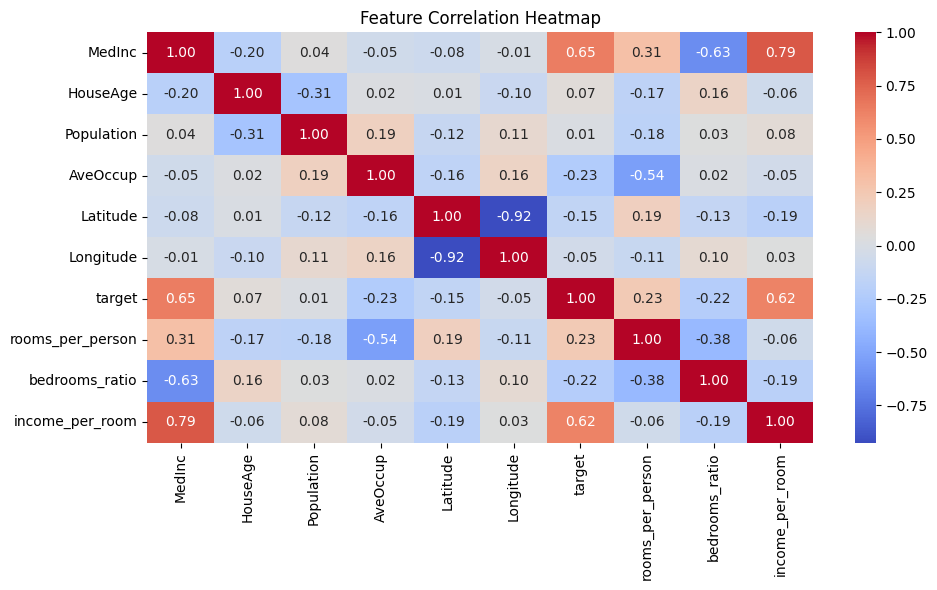

In [4]:
print("=== Dataset Info ===")
print(df.describe())

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

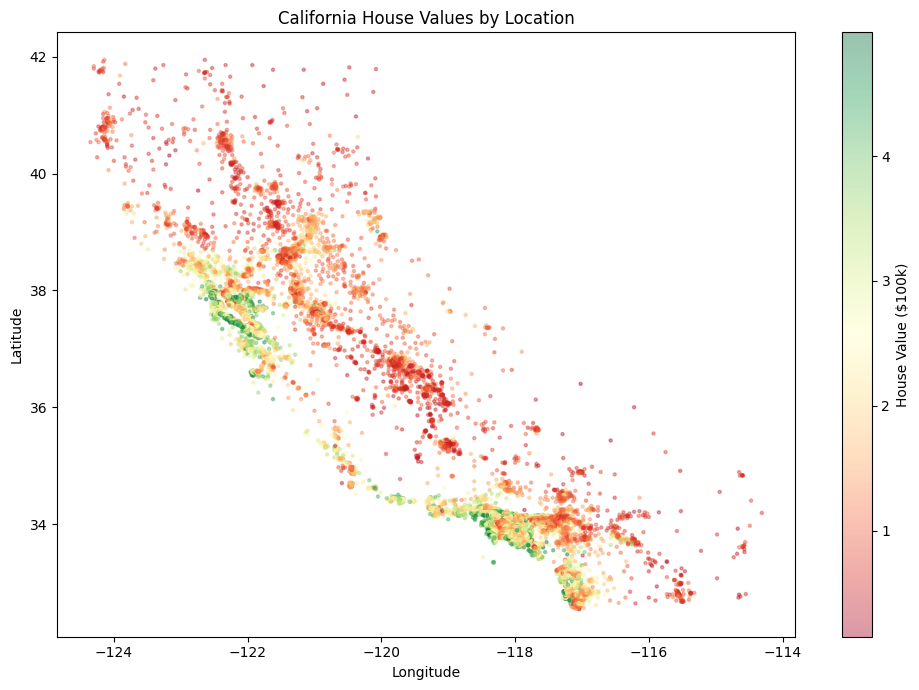

In [5]:
# Geographic price map — house value by lat/lon
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['target'], cmap='RdYlGn', alpha=0.4, s=5
)
plt.colorbar(scatter, label='House Value ($100k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California House Values by Location')
plt.tight_layout()
plt.show()

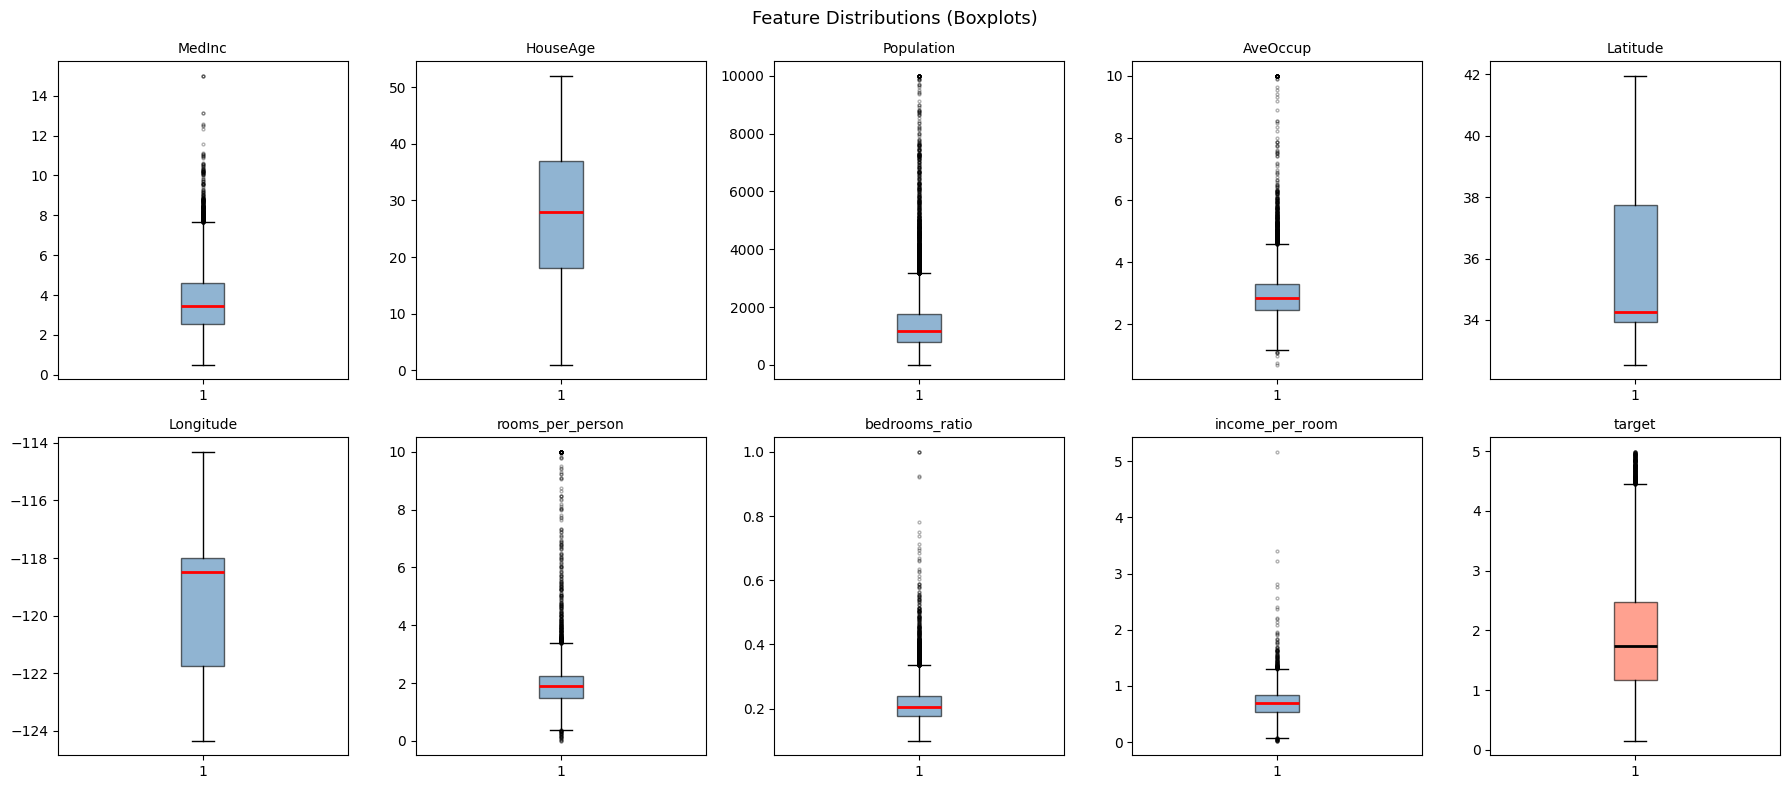

In [6]:
# Boxplots — distribution and outlier check for all numeric features
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

features = [c for c in df.columns if c != 'target']
for ax, feat in zip(axes.flat, features):
    ax.boxplot(df[feat].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')

# Use last subplot for target
axes.flat[len(features)].boxplot(df['target'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='tomato', alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes.flat[len(features)].set_title('target', fontsize=10)

# Hide any unused subplots
for ax in axes.flat[len(features)+1:]:
    ax.set_visible(False)

plt.suptitle('Feature Distributions (Boxplots)', fontsize=13)
plt.tight_layout()
plt.show()

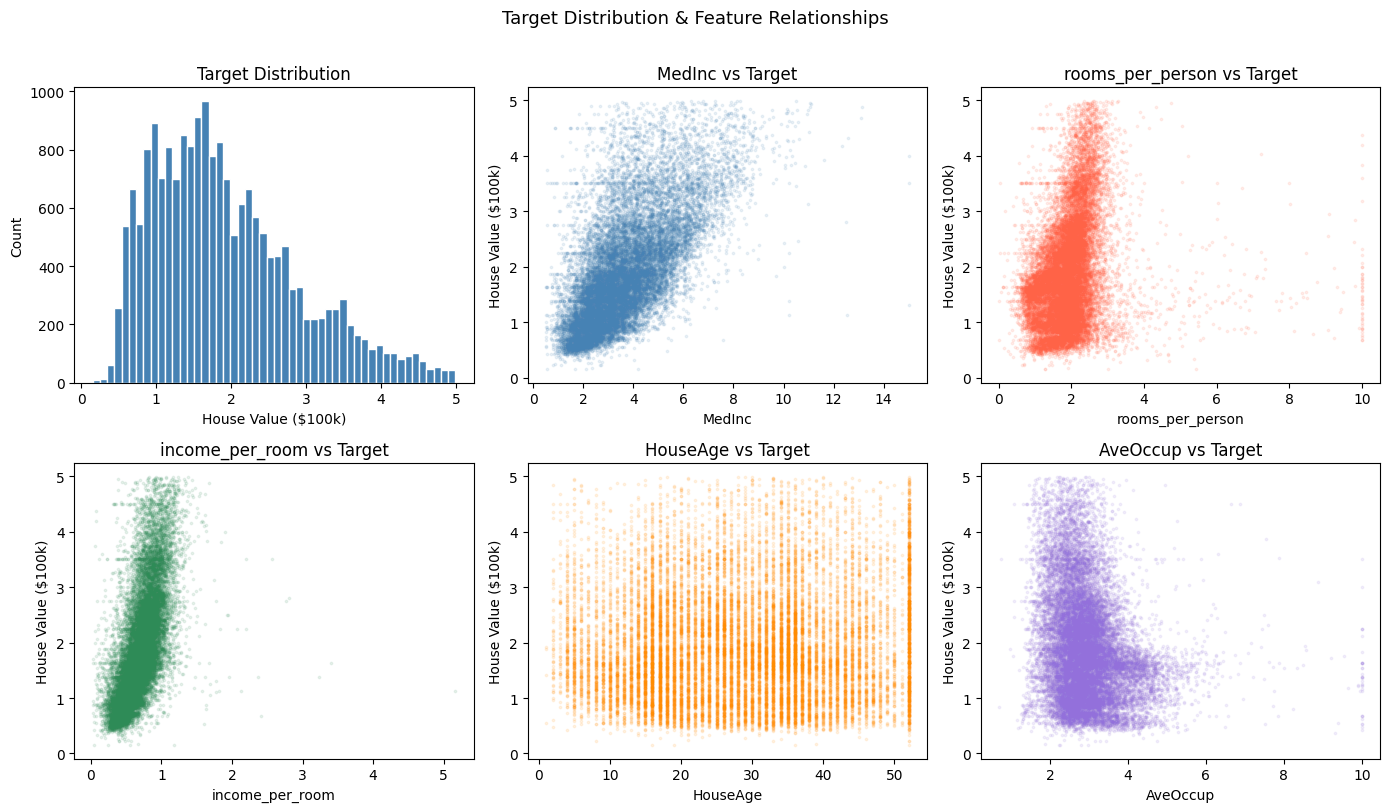

In [7]:
# Target distribution + scatter vs top features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Target distribution
axes[0, 0].hist(df['target'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Target Distribution')
axes[0, 0].set_xlabel('House Value ($100k)')
axes[0, 0].set_ylabel('Count')

# Top 5 features by absolute correlation with target
top_features = ['MedInc', 'rooms_per_person', 'income_per_room', 'HouseAge', 'AveOccup']
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

for ax, feat, color in zip(axes.flat[1:], top_features, colors):
    ax.scatter(df[feat], df['target'], alpha=0.1, s=3, color=color)
    ax.set_xlabel(feat)
    ax.set_ylabel('House Value ($100k)')
    ax.set_title(f'{feat} vs Target')

plt.suptitle('Target Distribution & Feature Relationships', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Preprocessing — Train/Test Split & Scaling

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (15718, 9)
Test size: (3930, 9)


## 6. Model Training

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model trained!")

Model trained!


## 7. Evaluation

RMSE: 0.4616
MAE:  0.3083
R²:   0.7778


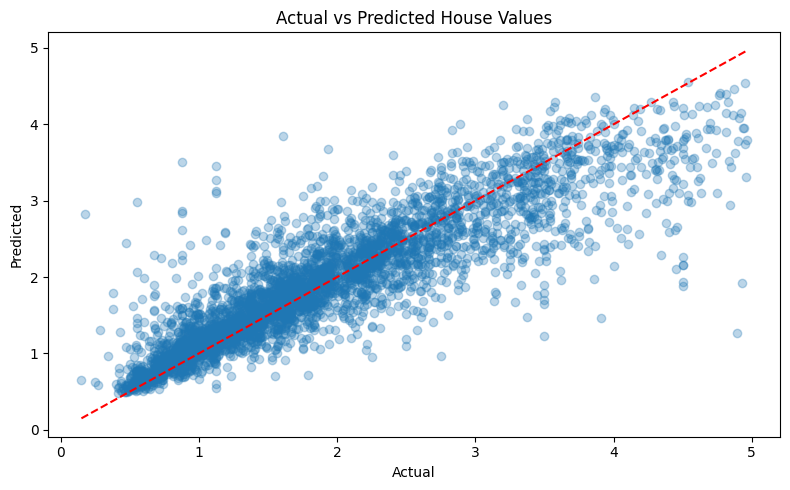

In [10]:
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted House Values")
plt.tight_layout()
plt.show()

## 8. Save Model Artifacts

In [11]:
joblib.dump(model, "../../ml/artifacts/rf_housing.pkl")
joblib.dump(scaler, "../../ml/artifacts/rf_housing_scaler.pkl")
print("Model saved to ml/artifacts/rf_housing.pkl")

Model saved to ml/artifacts/rf_housing.pkl


---

## 📋 Executive Summary — California Housing Price Model

### What We Built
A **Random Forest regression model** that predicts California median home values (in $100k) at the census-block level. The model was trained on ~19,600 records after data cleaning and feature engineering.

---

### How It Works — in Plain Terms
The model learns patterns from 9 inputs about a neighborhood:

| Feature | What It Captures |
|---|---|
| `MedInc` | Median household income — strongest predictor of home value |
| `HouseAge` | Age of the housing stock |
| `Population` | Block-level population (capped at 10,000) |
| `AveOccup` | Average occupants per household (crowding) |
| `Latitude` / `Longitude` | Geographic location — encodes coastal premium, urban cores |
| `rooms_per_person` | Space per occupant — proxy for quality/comfort |
| `bedrooms_ratio` | Bedroom share of total rooms |
| `income_per_room` | Income relative to home size |

A Random Forest builds hundreds of decision trees, each trained on a random slice of the data, and averages their predictions. This makes it robust to outliers and able to capture non-linear relationships (e.g., the income-to-value relationship isn't a straight line).

---

### Model Performance

| Metric | Value | What It Means |
|---|---|---|
| **R²** | **0.78** | The model explains 78% of the variance in home prices |
| **RMSE** | **$46,160** | Typical prediction is off by ~$46k |
| **MAE** | **$30,830** | On average, predictions are within ~$31k of actual |

**Context:** The average home in this dataset is worth ~$192k. An average error of ~$31k represents roughly a **16% margin**, which is competitive for a single-model baseline with no hyperparameter tuning.

---

### Key Findings from Exploratory Analysis

1. **Income is the dominant driver.** `MedInc` has the highest correlation with home value (~0.69). Neighborhoods with higher median incomes consistently command higher prices.

2. **Location matters enormously.** The geographic scatter plot clearly shows the coastal premium — the Bay Area and LA basin have the highest concentrations of high-value homes.

3. **Crowding suppresses value.** Higher `AveOccup` (more people per household) is associated with lower home prices, even after controlling for income.

4. **Extreme outliers were handled.** A small number of records had implausible occupancy values (e.g., 1,000+ per household), likely data artifacts. These were capped rather than dropped to preserve sample size.

5. **Censored values removed.** The dataset caps reported home values at $500k. These 992 rows (~5%) were excluded from training because they represent an artificial ceiling, not real price distributions — keeping them would bias the model to underpredict in high-value areas.

---

### Limitations & Next Steps

- **No hyperparameter tuning yet** — cross-validated grid search on `n_estimators`, `max_depth`, and `min_samples_leaf` could push R² above 0.82+
- **Gradient boosting (XGBoost/LightGBM)** typically outperforms Random Forest on tabular regression — worth benchmarking
- **Feature importance analysis** would quantify each variable's contribution and support feature selection
- **Residual analysis** could reveal systematic under/over-prediction by region or price tier
- **Temporal data** is unavailable here — in production, time-of-sale and interest rate data would significantly improve accuracy
